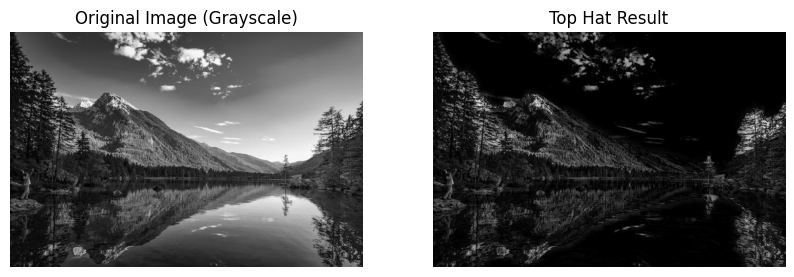

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the 'park image.avif'
# Ensure the image path is correct. If it's in the current directory, just the filename is sufficient.
img_color = cv2.imread('/content/park image.avif')

# Check if image loaded successfully
if img_color is None:
    print("Error: Could not load the image. Please check the path.")
    # Exit or handle the error appropriately
else:
    # Convert the image to grayscale for morphological operations
    img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image (Grayscale)')
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    # Define the kernel for morphological operations
    # Adjust this size based on the foreground object size you want to highlight
    kernel_size = (15, 15) # Increased kernel size for potentially larger features in a real image
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)

    # Apply the Top Hat (White Hat) morphological operation
    # Top Hat = Original Image - Opening(Original Image)
    # It highlights small bright objects on a dark background.
    tophat_img = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

    # Display the Top Hat result
    plt.subplot(1, 2, 2)
    plt.title('Top Hat Result')
    plt.imshow(tophat_img, cmap='gray')
    plt.axis('off')

    plt.show()


The `tophat_img` shows the bright foreground region extracted from the background. If you wish to further dilate this extracted foreground, you can apply a dilation operation on the `tophat_img`:

```python
# If you want to dilate the *result* of the Top Hat operation:

# Define a dilation kernel (can be the same or different from the tophat kernel)
dilation_kernel_size = (3, 3)
dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, dilation_kernel_size)

# Apply dilation to the tophat_img
dilated_tophat = cv2.dilate(tophat_img, dilation_kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Top Hat Result')
plt.imshow(tophat_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Dilated Top Hat Result')
plt.imshow(dilated_tophat, cmap='gray')
plt.axis('off')
plt.show()
```